# Module 2: Practice 1 — Probability (Colab-compatible)

The goal of this practical is to get hands-on experience with probability concepts and establish the theoretical footing for later parts of the course.

The math formulas you’ll see may feel overwhelming at first, but don’t worry — the point is to develop intuition. Come back to these examples throughout the semester to reinforce your understanding.

We'll start with **Bayes' Theorem** using a simplified "treasure hunt" game, then build intuition for **entropy**, **cross-entropy**, and **KL divergence** — the ideas behind the loss functions used later in the course.

You can:

Pick a guess (a grid cell).

Simulate an observed clue (distance with noise).

Compute the posterior distribution using Bayes’ rule.

We then visualize:

The prior (uniform grid).

The posterior heatmap showing which cells are most likely to contain the treasure.



In [ ]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.stats import norm
import math


## Example: Treasure Hunt + Bayes' Theorem

**Rules (simplified):**
- Grid: 5 × 5 (cells indexed 0..4).
- Treasure is hidden in one cell (unknown to the player).
- You make a guess and the game returns a **noisy distance clue** — roughly the Manhattan distance between your guess and the treasure.
- Clue noise: 80% chance of the exact distance, 10% chance off by +1, 10% chance off by −1.

**The idea in one sentence:**
We start believing the treasure is *equally likely* anywhere on the grid, and every clue we receive *shifts that belief*. That's Bayes' theorem:

$$P(\text{cell} \mid \text{clue}) \;\propto\; \underbrace{P(\text{clue} \mid \text{cell})}_{\text{likelihood}} \times \underbrace{P(\text{cell})}_{\text{prior}}$$

In plain English: **new belief = how well the clue fits this cell × how much we already believed in this cell.**

We start with a uniform prior (every cell equally likely) and watch the heatmap update.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prob_grid(prob_grid, guesses=None, title='Probability grid (row, col)'):
    """
    Show a heatmap of the probability grid with numeric annotations.
    `guesses` is a list of (row, col) tuples that will be marked.
    """
    size = prob_grid.shape[0]
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(prob_grid, origin='upper')
    vmax = prob_grid.max() if prob_grid.size > 0 else 1.0

    for i in range(size):
        for j in range(size):
            txt = f"{prob_grid[i,j]:.3f}"
            # pick text color so numbers are legible
            color = 'white' if prob_grid[i,j] > vmax/2 else 'black'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=10)

    if guesses:
        for g in guesses:
            # note: scatter uses (x=col, y=row)
            ax.scatter(g[1], g[0], s=220, facecolors='none', edgecolors='red', linewidths=2)
            ax.text(g[1], g[0], 'X', color='red', fontsize=14, ha='center', va='center')

    ax.set_xticks(np.arange(size))
    ax.set_yticks(np.arange(size))
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

def pretty_print_grid(prob_grid):
    """Print grid as rows for quick text view."""
    with np.printoptions(precision=3, suppress=True):
        print(prob_grid)


Matplotlib is building the font cache; this may take a moment.


In [4]:
class BayesianTreasureHunt:
    """
    Bayesian treasure hunt with noisy Manhattan-distance clues.

    Noise model:
      - 80% chance: exact true distance
      - 10% chance: true distance + 1
      - 10% chance: true distance - 1 (but never below 0)
    """
    def __init__(self, grid_size=5, seed=None, p_exact=0.8, p_off1=0.1):
        self.grid_size = int(grid_size)
        self.rng = np.random.default_rng(seed)
        self.p_exact = float(p_exact)   # now 0.8
        self.p_off1 = float(p_off1)     # now 0.1
        self.reset_game()

    def reset_game(self):
        self.treasure = (int(self.rng.integers(self.grid_size)),
                         int(self.rng.integers(self.grid_size)))
        # uniform prior
        self.prior = np.full((self.grid_size, self.grid_size),
                             1.0 / (self.grid_size**2))
        self.guesses = []
        self.iterations = 0
        self.last_clue = None

    def provide_clue(self, guess):
        """Return the noisy clue. If guess==treasure, return 0 (found)."""
        if guess == self.treasure:
            return 0
        true_distance = abs(guess[0] - self.treasure[0]) + abs(guess[1] - self.treasure[1])
        # noise distribution: [0, -1, +1] with [0.8, 0.1, 0.1]
        noise = self.rng.choice([0, -1, 1], p=[0.8, 0.1, 0.1])
        return max(0, true_distance + noise)

    def update_probabilities(self, guess, distance_clue):
        """Bayesian posterior update: P(cell | clue) ∝ P(clue | cell) * prior"""
        size = self.grid_size
        prior = self.prior.copy()
        prior[guess] = 0.0  # already checked

        # Manhattan distances from guess for all cells
        r = np.arange(size)[:, None]
        c = np.arange(size)[None, :]
        distances = np.abs(r - guess[0]) + np.abs(c - guess[1])

        # likelihood array
        likelihood = np.zeros_like(prior)
        likelihood[distances == distance_clue] = self.p_exact     # 0.8
        likelihood[np.abs(distances - distance_clue) == 1] = self.p_off1  # 0.1

        posterior_unnorm = prior * likelihood
        total = posterior_unnorm.sum()

        if total == 0:
            posterior = prior.copy()
            s = posterior.sum()
            if s == 0:
                posterior = np.full_like(prior, 1.0 / (size * size))
            else:
                posterior /= s
        else:
            posterior = posterior_unnorm / total

        self.prior = posterior

    def play_manual(self, guess):
        if not (0 <= guess[0] < self.grid_size and 0 <= guess[1] < self.grid_size):
            raise ValueError("Guess out of range. Use 0..grid_size-1 for row and col.")

        if guess in self.guesses:
            print("Note: you already guessed that cell before.")

        self.guesses.append(guess)
        self.iterations += 1

        if guess == self.treasure:
            self.last_clue = 0
            print(f"You found the treasure in {self.iterations} moves! Location: {guess}")
            p = np.zeros_like(self.prior)
            p[guess] = 1.0
            self.prior = p
            return 0

        clue = self.provide_clue(guess)
        self.last_clue = clue
        self.update_probabilities(guess, clue)
        print(f"Guess {guess} → distance clue: {clue}")
        return clue

    def suggest_next(self):
        """Return the (row, col) with highest posterior probability."""
        idx = np.unravel_index(np.argmax(self.prior, axis=None), self.prior.shape)
        return idx

    def reveal_treasure(self):
        """Teacher-only: reveal treasure location."""
        return self.treasure


Treasure location: (3, 4)


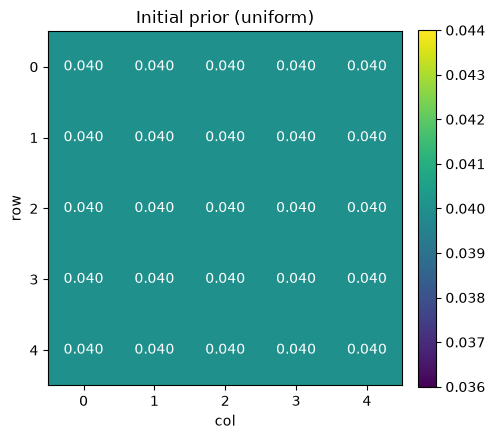

Guess (2, 2) → distance clue: 3


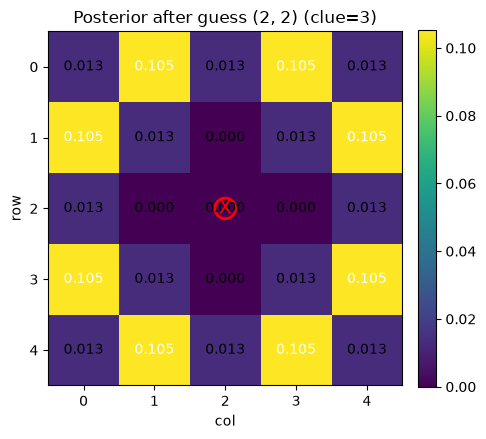

Suggested next guess (highest posterior): (np.int64(0), np.int64(1))


In [5]:
game = BayesianTreasureHunt(grid_size=5, seed=41)  # deterministic for demo; remove seed for random
print("Treasure location:", game.reveal_treasure())  # Location of actual treasure

# 1) show initial prior (uniform)
plot_prob_grid(game.prior, guesses=game.guesses, title="Initial prior (uniform)")

# 2) student selects a guess manually, e.g., (2, 2)
guess = (2, 2)   # students pick this cell
clue = game.play_manual(guess)

# 3) view posterior after the update
plot_prob_grid(game.prior, guesses=game.guesses, title=f"Posterior after guess {guess} (clue={clue})")

# 4) suggestion for next pick (if student wants)
print("Suggested next guess (highest posterior):", game.suggest_next())


Guess (0, 1) → distance clue: 6


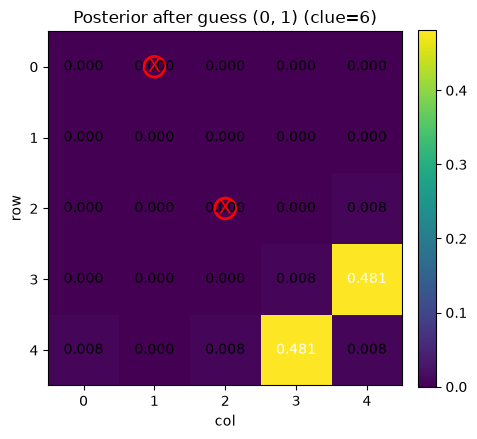

In [12]:
# Student tries a second guess
next_guess = (0, 1)   # <-- pick any row, col you like
clue = game.play_manual(next_guess)

# View the updated posterior again
plot_prob_grid(game.prior, guesses=game.guesses,
               title=f"Posterior after guess {next_guess} (clue={clue})")


## Example 2 — Entropy: how "unsure" is a distribution?

**Entropy** is a single number that answers: *"On average, how surprised will I be by the next sample?"*

- **High entropy** → very spread out, unpredictable (a fair die).
- **Low entropy** → concentrated, predictable (a loaded die that lands 6 almost always).

The formula:

$$H(P) = -\sum_i P(x_i)\,\log P(x_i)$$

Why we care: later in the course, models will output a *probability distribution over next tokens*. Entropy tells us **how confident the model is** — low entropy = confident guess, high entropy = "I have no idea".

Play with `color_counts` below. Try `[10, 0, 0]` (entropy → 0) vs `[1, 1, 1]` (max entropy).


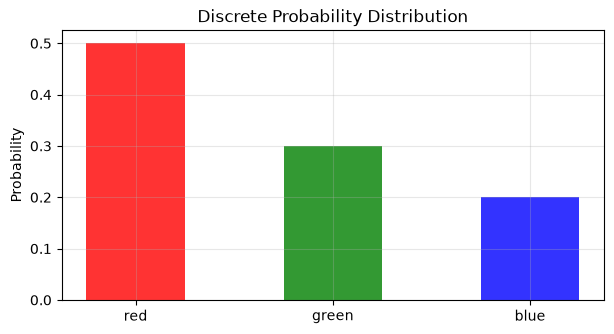

probabilities : [0.5 0.3 0.2]
entropy H(P)  : 1.0297


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# A discrete distribution over 3 box colors. Edit the counts to explore entropy.
colors = ["red", "green", "blue"]
color_counts = np.array([5, 3, 2])
color_probs = color_counts / color_counts.sum()

plt.figure(figsize=(7, 3.5))
plt.bar(colors, color_probs, color=colors, width=0.5, alpha=0.8)
plt.ylabel("Probability")
plt.title("Discrete Probability Distribution")
plt.grid(True, alpha=0.3)
plt.show()

# Entropy: H(P) = - sum_i  P(x_i) * log P(x_i)
entropy = float(-np.sum([p * np.log(p) for p in color_probs if p > 0]))
print(f"probabilities : {np.round(color_probs, 3)}")
print(f"entropy H(P)  : {entropy:.4f}")
